In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
import os
os.environ["GROQ_API_KEY"][:6] + "..."

'gsk_0o...'

In [3]:
val = pd.read_csv("../data/processed/val_with_scores.csv")

with open("../data/processed/content_embeddings.pkl", "rb") as f:
    content_data = pickle.load(f)

doc_id_to_idx = content_data["doc_id_to_idx"]
content_embeddings = content_data["embeddings"]

In [4]:
def get_content_vector(doc_id):
    idx = doc_id_to_idx.get(doc_id)
    if idx is None:
        return np.zeros(content_embeddings.shape[1], dtype=np.float32)
    return content_embeddings[idx]

In [5]:
documents_categories = pd.read_csv("../data/raw/documents_categories.csv.zip")
documents_topics = pd.read_csv("../data/raw/documents_topics.csv.zip")

category_map = documents_categories.groupby("document_id")["category_id"].apply(set).to_dict()
topic_map = documents_topics.groupby("document_id")["topic_id"].apply(set).to_dict()

def jaccard_similarity(doc_a, doc_b):
    cat_a, cat_b = category_map.get(doc_a, set()), category_map.get(doc_b, set())
    topic_a, topic_b = topic_map.get(doc_a, set()), topic_map.get(doc_b, set())

    union = cat_a | cat_b | topic_a | topic_b
    if not union:
        return 0
    intersection = (cat_a & cat_b) | (topic_a & topic_b)
    return len(intersection) / len(union)

In [6]:
#MMR 재랭킹 함수

def mmr_rerank(candidates, lam=0.7, top_k=5):
    selected = []
    pool = candidates.copy()
    while pool and len(selected) < top_k:
        best, best_score = None, -np.inf
        for doc_id, relevance in pool:
            if not selected:
                sim = 0
            else:
                sim = max(jaccard_similarity(doc_id, s) for s, _ in selected)
            mmr_score = lam * relevance - (1 - lam) * sim
            if mmr_score > best_score:
                best, best_score = (doc_id, relevance), mmr_score
        selected.append(best)
        pool.remove(best)
    return selected

In [7]:
# 다양성 지표(ILD)
def intra_list_diversity(selected_ids):
    if len(selected_ids) < 2:
        return 0
    dists = []
    for i in range(len(selected_ids)):
        for j in range(i + 1, len(selected_ids)):
            sim = jaccard_similarity(selected_ids[i], selected_ids[j])
            dists.append(1 - sim)
    return np.mean(dists)

In [8]:
sample_display_ids = val["display_id"].drop_duplicates().sample(5000, random_state=42)
val_small = val[val["display_id"].isin(sample_display_ids)]

results = []
for lam in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    hit_list, ild_list = [], []
    for display_id, group in val_small.groupby("display_id"):
        candidates = list(zip(group["document_id_ad"], group["score_session"]))
        selected = mmr_rerank(candidates, lam=lam, top_k=5)
        selected_ids = [doc_id for doc_id, _ in selected]

        clicked_docs = group.loc[group["clicked"] == 1, "document_id_ad"].values
        hit_list.append(any(d in clicked_docs for d in selected_ids))
        ild_list.append(intra_list_diversity(selected_ids))

    results.append({"lambda": lam, "hit_rate": np.mean(hit_list), "diversity": np.mean(ild_list)})

results_df = pd.DataFrame(results)
results_df

,lambda,hit_rate,diversity
0,0.5,0.9174,0.952966
1,0.6,0.9176,0.952083
2,0.7,0.9270,0.950271
3,0.8,0.9326,0.946879
4,0.9,0.9392,0.941851
5,1.0,0.9396,0.935955


Text(0, 0.5, 'hit rate')

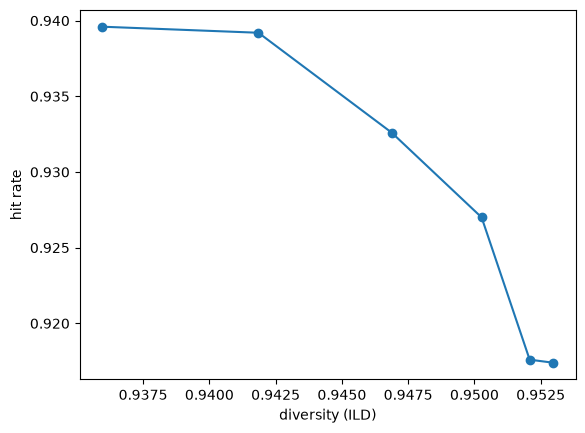

In [9]:
plt.plot(results_df["diversity"], results_df["hit_rate"], marker="o")
plt.xlabel("diversity (ILD)")
plt.ylabel("hit rate")

In [10]:
session_sizes = val_small.groupby("display_id").size()
(session_sizes > 5).mean()

np.float64(0.4444)

In [11]:
from openai import OpenAI

In [12]:
from openai import OpenAI

client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=os.environ["GROQ_API_KEY"],
)

def explain_rerank(before_ids, after_ids, lam):
    before_ild = intra_list_diversity(before_ids)
    after_ild = intra_list_diversity(after_ids)

    prompt = f"""추천 시스템의 재랭킹 결과를 설명해.
- lambda(관련성 가중치): {lam}
- 재랭킹 전 다양성 점수(ILD): {before_ild:.3f}
- 재랭킹 후 다양성 점수(ILD): {after_ild:.3f}
- 후보 수: {len(before_ids)}, 최종 노출 수: {len(after_ids)}

두 문장으로 다양성이 어떻게 바뀌었고 어떤 트레이드오프가 있었는지 설명해."""

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[{"role": "user", "content": prompt}],
    )
    return response.choices[0].message.content

In [13]:
sample_id = val_small["display_id"].iloc[0]
group = val_small[val_small["display_id"] == sample_id]
candidates = list(zip(group["document_id_ad"], group["score_session"]))

before_ids = [d for d, _ in sorted(candidates, key=lambda x: -x[1])[:5]]
after_selected = mmr_rerank(candidates, lam=0.7, top_k=5)
after_ids = [d for d, _ in after_selected]

explain_rerank(before_ids, after_ids, lam=0.7)

'The ILD stayed exactly at\u202f1.0 before and after re‑ranking, so the item heterogeneity of the list was preserved. By giving relevance a weight of\u202f0.7, the system boosted the relevance score of the three displayed items while keeping diversity intact, meaning the trade‑off between relevance and diversity was effectively neutral.'

In [14]:
sample_sessions = val_small["display_id"].drop_duplicates().sample(5, random_state=1)

explanation_samples = []
for did in sample_sessions:
    group = val_small[val_small["display_id"] == did]
    candidates = list(zip(group["document_id_ad"], group["score_session"]))

    before_ids = [d for d, _ in sorted(candidates, key=lambda x: -x[1])[:5]]
    after_selected = mmr_rerank(candidates, lam=0.7, top_k=5)
    after_ids = [d for d, _ in after_selected]

    explanation = explain_rerank(before_ids, after_ids, lam=0.7)
    explanation_samples.append({
        "display_id": int(did),
        "candidate_count": len(candidates),
        "before_ild": intra_list_diversity(before_ids),
        "after_ild": intra_list_diversity(after_ids),
        "explanation": explanation,
    })

pd.DataFrame(explanation_samples)

,display_id,candidate_count,before_ild,after_ild,explanation
0,9371558,9,0.977778,1.000000,재랭킹 전 ILD 0.978에서 재랭킹 후 1.000로 상승해 후보 중 모든 항목이...
1,16098770,6,0.710000,0.710000,"재랭킹 전후 ILD(다양성 점수)가 0.710으로 동일해, 후보 5개에서 5개를 최..."
2,12881130,4,0.937500,0.937500,다시 랭킹한 결과 ILD(Inter‑List Diversity) 점수가 0.938에...
3,11844735,5,1.000000,1.000000,ILD 점수는 1.000에서 1.000로 변하지 않아 재랭킹 과정에서 다양성은 완전...
4,9253439,6,0.982576,0.982576,재랭킹 전후 ILD 점수가 모두 0.983이므로 다양성은 그대로 유지되었습니다. ...


In [15]:
Path("../dashboard/data").mkdir(parents=True, exist_ok=True)

results_df.to_json("../dashboard/data/diversity_tradeoff.json", orient="records")
pd.DataFrame(explanation_samples).to_json(
    "../dashboard/data/explanation_samples.json", orient="records", force_ascii=False
)